
✅ DEVICE STATUS: cuda
   GPU Detected: NVIDIA GeForce RTX 5060
--- Loading & Augmenting Audio ---


100%|██████████| 920/920 [02:29<00:00,  6.15it/s]


✅ Data Ready: 9552 samples. Classes: ['Crackle' 'Normal' 'Wheeze']
⚖️ Class Weights: tensor([1.1528, 0.5818, 2.4176], device='cuda:0')

🔹 Fold 1/5 (ResNet34 + Bi-LSTM)


C:\Users\User\anaconda3\envs\Yolo-GPU\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\envs\Yolo-GPU\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


   Epoch 100: Loss 0.0628 | Val Acc 86.08%
   > Best Fold Acc: 89.22%

🔹 Fold 2/5 (ResNet34 + Bi-LSTM)
   Epoch 100: Loss 0.0846 | Val Acc 84.56%
   > Best Fold Acc: 88.96%

🔹 Fold 3/5 (ResNet34 + Bi-LSTM)
   Epoch 100: Loss 0.0777 | Val Acc 87.80%
   > Best Fold Acc: 89.01%

🔹 Fold 4/5 (ResNet34 + Bi-LSTM)
   Epoch 100: Loss 0.0866 | Val Acc 83.87%
   > Best Fold Acc: 88.12%

🔹 Fold 5/5 (ResNet34 + Bi-LSTM)
   Epoch 100: Loss 0.0850 | Val Acc 76.86%
   > Best Fold Acc: 88.95%


📊 FINAL SOTA RESULTS
              precision    recall  f1-score   support

     Crackle       0.74      0.84      0.79      2762
      Normal       0.89      0.83      0.86      5473
      Wheeze       0.84      0.85      0.85      1317

    accuracy                           0.84      9552
   macro avg       0.83      0.84      0.83      9552
weighted avg       0.84      0.84      0.84      9552



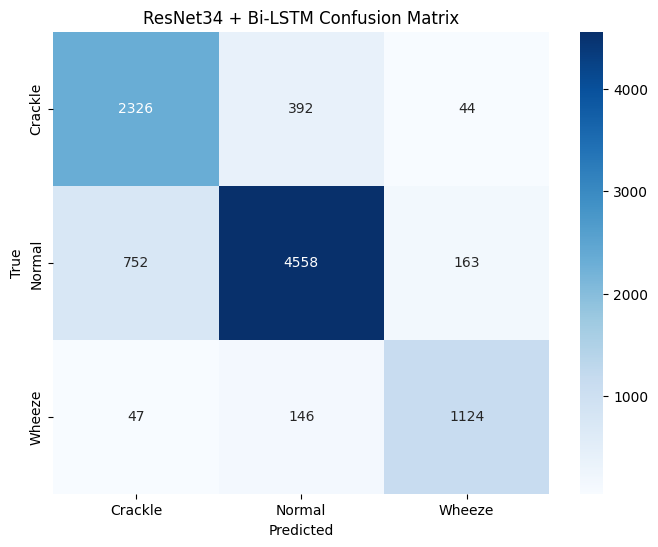


📈 GENERATING ROC-AUC CURVE...


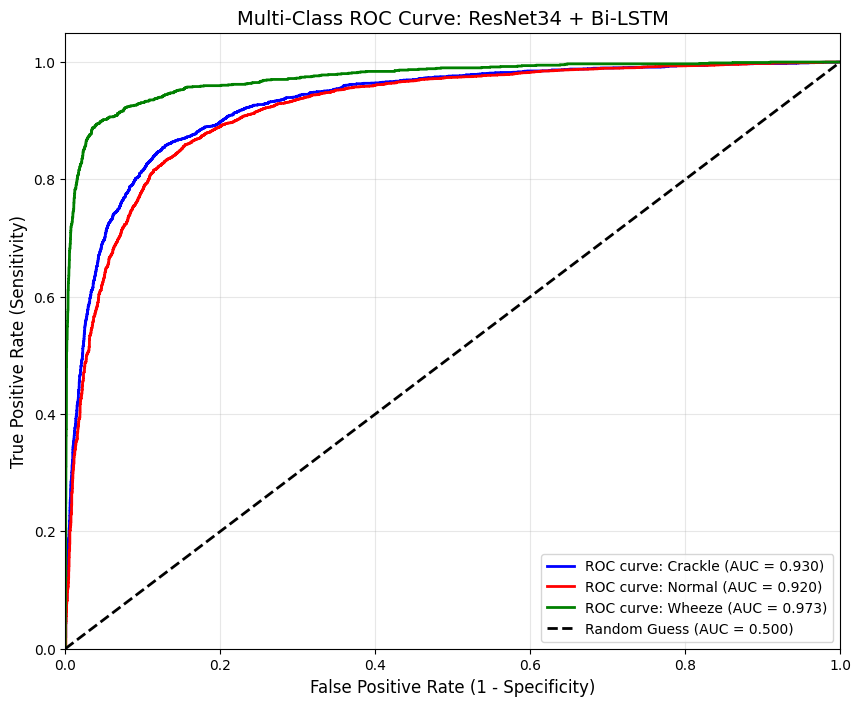

✅ ROC Curve saved to: results_sota\sota_roc_curve.png
✅ Model successfully saved to: ./saved_models/resnet34.pth


In [6]:
import os
import sys
import subprocess
import numpy as np
import pandas as pd
import scipy.signal
from tqdm import tqdm
from itertools import cycle # <-- NEW IMPORT

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize # <-- NEW IMPORT
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc # <-- NEW IMPORTS
from sklearn.utils.class_weight import compute_class_weight

# --- 1. SETUP & IMPORTS ---
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torchvision.models as models
    import librosa
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    print("⚠️ Installing missing libraries...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "torchaudio", "librosa", "matplotlib", "scikit-learn", "tqdm", "pandas", "scipy", "seaborn"])
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torchvision.models as models
    import librosa
    import matplotlib.pyplot as plt
    import seaborn as sns

# --- 2. GPU SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ DEVICE STATUS: {device}")
if torch.cuda.is_available():
    print(f"   GPU Detected: {torch.cuda.get_device_name(0)}")

# --- 3. CONFIGURATION ---
DATASET_DIR = 'dataset'
SAVE_DIR = 'results_sota'
os.makedirs(SAVE_DIR, exist_ok=True)

SAMPLE_RATE = 16000
MAX_DURATION = 5.0
MAX_SAMPLES = int(MAX_DURATION * SAMPLE_RATE)
N_MFCC = 13
N_MELS = 128
PREEMPHASIS_COEF = 0.97

# --- 4. DATA AUGMENTATION ---
def spec_augment(spec, num_mask=2, freq_masking=15, time_masking=20):
    spec = spec.clone()
    if spec.dim() == 4:
        freq_axis = 2
        time_axis = 3
    elif spec.dim() == 3:
        freq_axis = 1
        time_axis = 2
    else:
        return spec
        
    for _ in range(num_mask):
        f = np.random.randint(1, freq_masking)
        f_max = spec.shape[freq_axis] - f
        if f_max > 0:
            f0 = np.random.randint(0, f_max)
            if spec.dim() == 4:
                spec[:, :, f0:f0+f, :] = 0
            else:
                spec[:, f0:f0+f, :] = 0

        t = np.random.randint(1, time_masking)
        t_max = spec.shape[time_axis] - t
        if t_max > 0:
            t0 = np.random.randint(0, t_max)
            if spec.dim() == 4:
                spec[:, :, :, t0:t0+t] = 0
            else:
                spec[:, :, t0:t0+t] = 0
    return spec

def preemphasis(signal, coeff=0.97):
    return np.append(signal[0], signal[1:] - coeff * signal[:-1])

def fix_length(y):
    if len(y) > MAX_SAMPLES:
        start = np.random.randint(0, len(y) - MAX_SAMPLES)
        return y[start : start + MAX_SAMPLES]
    else:
        return np.pad(y, (0, MAX_SAMPLES - len(y)))

def extract_features(y, sr):
    y = preemphasis(y, coeff=PREEMPHASIS_COEF)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=512)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    cnn_input = mel_db.astype(np.float32) 
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=512)
    lstm_input = mfcc.T.astype(np.float32) 
    return cnn_input, lstm_input

def augment_audio(y, sr):
    augmented = [y]
    if np.random.rand() > 0.5: 
        steps = np.random.randint(-2, 2)
        try:
            y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)
            augmented.append(fix_length(y_pitch))
        except: pass
    return augmented

# --- 5. DATA LOADING ---
def load_data(path):
    X_cnn, X_lstm, y_labels = [], [], []
    wav_files = []
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.endswith('.wav'):
                wav_files.append(os.path.join(root, f))
    
    print(f"--- Loading & Augmenting Audio ---")
    for wav_path in tqdm(wav_files):
        try:
            y, sr = librosa.load(wav_path, sr=SAMPLE_RATE)
            txt_file = wav_path.replace('.wav', '.txt')
            
            if os.path.exists(txt_file):
                df_labels = pd.read_csv(txt_file, sep='\t', names=['start','end','c','w'])
                for _, row in df_labels.iterrows():
                     if row['end'] - row['start'] < 0.2: continue 
                     y_seg = y[int(row['start']*sr):int(row['end']*sr)]
                     if len(y_seg) == 0: continue
                     
                     label = 'Normal'
                     if row['c'] == 1 and row['w'] == 1: label = 'Both'
                     elif row['c'] == 1: label = 'Crackle'
                     elif row['w'] == 1: label = 'Wheeze'
                     
                     if label == 'Both': continue 
                     
                     variations = augment_audio(fix_length(y_seg), sr)
                     for v in variations:
                         xc, xl = extract_features(v, sr)
                         X_cnn.append(xc)
                         X_lstm.append(xl)
                         y_labels.append(label)
        except: pass
            
    return np.array(X_cnn), np.array(X_lstm), np.array(y_labels)

# --- 6. THE SOTA MODEL (ResNet34 + LSTM) ---
class SOTADualModel(nn.Module):
    def __init__(self, num_classes):
        super(SOTADualModel, self).__init__()
        self.resnet = models.resnet34(pretrained=True)
        original_weights = self.resnet.conv1.weight.data.mean(dim=1, keepdim=True)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.resnet.conv1.weight.data = original_weights
        self.resnet.fc = nn.Identity()
        
        self.lstm = nn.LSTM(input_size=13, hidden_size=128, num_layers=2, batch_first=True, bidirectional=True)
        
        self.fusion = nn.Sequential(
            nn.Linear(512 + 256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4), 
            nn.Linear(256, num_classes)
        )

    def forward(self, x_cnn, x_lstm):
        x_cnn = nn.functional.interpolate(x_cnn, size=(224, 224), mode='bilinear', align_corners=False)
        features_cnn = self.resnet(x_cnn) 
        
        _, (h_n, _) = self.lstm(x_lstm)
        features_lstm = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1) 
        
        combined = torch.cat((features_cnn, features_lstm), dim=1)
        return self.fusion(combined)

class LungDataset(Dataset):
    def __init__(self, X_cnn, X_lstm, y):
        self.X_cnn = X_cnn
        self.X_lstm = X_lstm
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        c = torch.tensor(self.X_cnn[idx], dtype=torch.float32).unsqueeze(0)
        l = torch.tensor(self.X_lstm[idx], dtype=torch.float32)
        return c, l, self.y[idx]

# --- 7. MAIN TRAINING LOOP ---
if __name__ == "__main__":
    X_cnn, X_lstm, y_raw = load_data(DATASET_DIR)
    le = LabelEncoder()
    y_enc = le.fit_transform(y_raw)
    classes = le.classes_
    print(f"✅ Data Ready: {len(X_cnn)} samples. Classes: {classes}")

    class_weights = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print(f"⚖️ Class Weights: {class_weights}")

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # --- NEW: Added global_probs to store probabilities for ROC calculation ---
    global_trues, global_preds, global_probs = [], [], [] 
    best_overall_acc = 0

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cnn, y_enc)):
        print(f"\n🔹 Fold {fold+1}/5 (ResNet34 + Bi-LSTM)")
        
        train_ds = LungDataset(X_cnn[train_idx], X_lstm[train_idx], y_enc[train_idx])
        val_ds = LungDataset(X_cnn[val_idx], X_lstm[val_idx], y_enc[val_idx])
        
        # --- FIX: drop_last=True added here to prevent BatchNorm errors ---
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0, drop_last=True) 
        val_loader = DataLoader(val_ds, batch_size=32, num_workers=0)
        
        model = SOTADualModel(len(classes)).to(device)
        optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        
        best_fold_acc = 0
        
        for epoch in range(100): 
            model.train()
            train_loss = 0
            for xc, xl, y in train_loader:
                xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                
                if np.random.rand() > 0.4: 
                    xc = spec_augment(xc)
                
                optimizer.zero_grad()
                out = model(xc, xl)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            
            scheduler.step()
            
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for xc, xl, y in val_loader:
                    xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                    out = model(xc, xl)
                    _, pred = torch.max(out, 1)
                    total += y.size(0)
                    correct += (pred == y).sum().item()
            
            acc = 100 * correct / total
            if acc > best_fold_acc: best_fold_acc = acc
            print(f"   Epoch {epoch+1:02d}: Loss {train_loss/len(train_loader):.4f} | Val Acc {acc:.2f}%", end='\r')
        
        print(f"\n   > Best Fold Acc: {best_fold_acc:.2f}%")
        
        # --- NEW: Extracting Probabilities for ROC ---
        with torch.no_grad():
            for xc, xl, y in val_loader:
                xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                out = model(xc, xl)
                
                # Convert raw output logits to probabilities via Softmax
                probs = torch.softmax(out, dim=1) 
                _, pred = torch.max(out, 1)
                
                global_trues.extend(y.cpu().numpy())
                global_preds.extend(pred.cpu().numpy())
                global_probs.extend(probs.cpu().numpy()) # Store probabilities

    # --- 8. RESULTS ---
    print("\n\n📊 FINAL SOTA RESULTS")
    print(classification_report(global_trues, global_preds, target_names=classes))
    
    # --- CONFUSION MATRIX ---
    cm = confusion_matrix(global_trues, global_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title("ResNet34 + Bi-LSTM Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(os.path.join(SAVE_DIR, 'sota_confusion_matrix.png'))
    plt.show()

    # --- 9. NEW: ROC & AUC PLOTTING LOGIC ---
    print("\n📈 GENERATING ROC-AUC CURVE...")
    
    # Convert labels to binary format for multi-class plotting (e.g., class 2 -> [0, 0, 1])
    y_bin = label_binarize(global_trues, classes=range(len(classes)))
    n_classes = y_bin.shape[1]
    global_probs_arr = np.array(global_probs)

    # Calculate False Positive Rate (FPR), True Positive Rate (TPR), and Area Under Curve (AUC)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], global_probs_arr[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot the ROC curves
    
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'purple', 'orange'])
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve: {classes[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Multi-Class ROC Curve: ResNet34 + Bi-LSTM', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    
    roc_path = os.path.join(SAVE_DIR, 'sota_roc_curve.png')
    plt.savefig(roc_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ ROC Curve saved to: {roc_path}")

    # Save the model weights
    os.makedirs('./saved_models', exist_ok=True)
    save_path = './saved_models/resnet34.pth'
    torch.save(model.state_dict(), save_path)
    print(f"✅ Model successfully saved to: {save_path}")


✅ DEVICE STATUS: cuda
   GPU Detected: NVIDIA GeForce RTX 5060
--- Loading & Augmenting Audio ---


100%|██████████| 920/920 [02:23<00:00,  6.41it/s]


✅ Data Ready: 9575 samples. Classes: ['Crackle' 'Normal' 'Wheeze']
⚖️ Class Weights: tensor([1.1502, 0.5828, 2.4106], device='cuda:0')

🔹 Fold 1/5 (ResNet18 + Bi-LSTM)


C:\Users\User\anaconda3\envs\Yolo-GPU\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\envs\Yolo-GPU\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


   Epoch 100: Loss 0.1138 | Val Acc 83.39%
   > Best Fold Acc: 88.72%

🔹 Fold 2/5 (ResNet18 + Bi-LSTM)
   Epoch 100: Loss 0.0935 | Val Acc 86.16%
   > Best Fold Acc: 89.71%

🔹 Fold 3/5 (ResNet18 + Bi-LSTM)
   Epoch 100: Loss 0.0718 | Val Acc 84.96%
   > Best Fold Acc: 88.93%

🔹 Fold 4/5 (ResNet18 + Bi-LSTM)
   Epoch 100: Loss 0.0881 | Val Acc 82.19%
   > Best Fold Acc: 88.62%

🔹 Fold 5/5 (ResNet18 + Bi-LSTM)
   Epoch 100: Loss 0.0748 | Val Acc 86.01%
   > Best Fold Acc: 87.10%


📊 FINAL SOTA RESULTS
              precision    recall  f1-score   support

     Crackle       0.77      0.83      0.80      2775
      Normal       0.89      0.85      0.87      5476
      Wheeze       0.83      0.86      0.84      1324

    accuracy                           0.85      9575
   macro avg       0.83      0.85      0.84      9575
weighted avg       0.85      0.85      0.85      9575



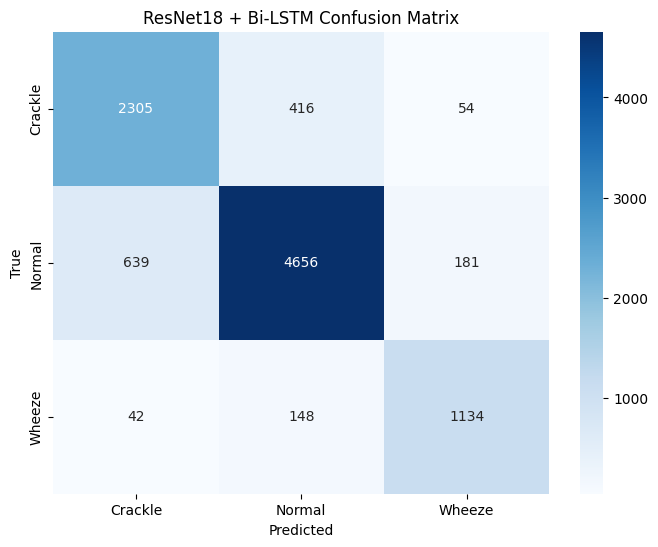


📈 GENERATING ROC-AUC CURVE...


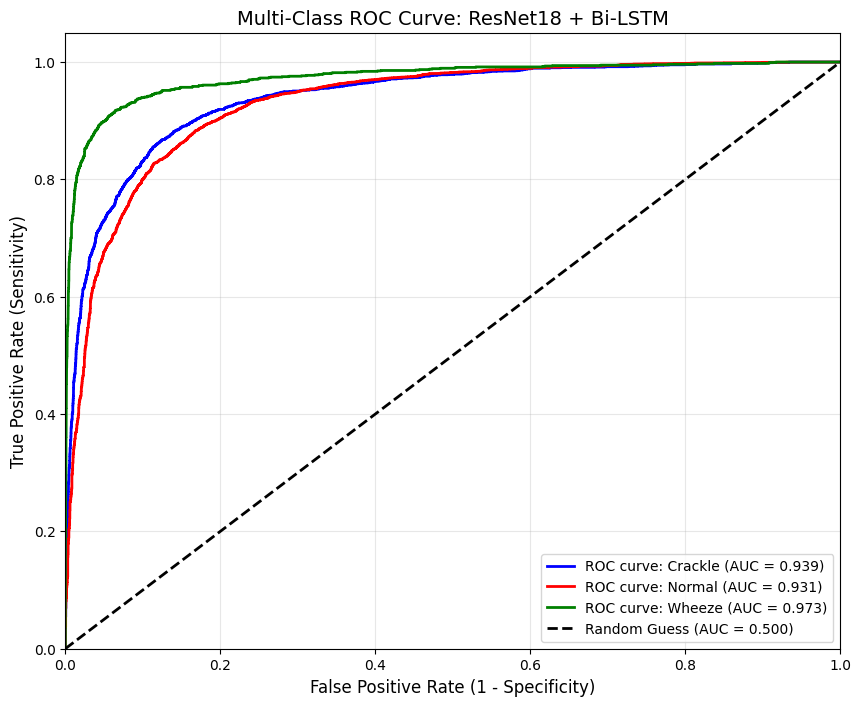

✅ ROC Curve saved to: results_sota\sota_roc_curve.png
✅ Model successfully saved to: ./saved_models/resnet18.pth


In [7]:
 import os
import sys
import subprocess
import numpy as np
import pandas as pd
import scipy.signal
from tqdm import tqdm
from itertools import cycle # <-- NEW IMPORT

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize # <-- NEW IMPORT
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc # <-- NEW IMPORTS
from sklearn.utils.class_weight import compute_class_weight

# --- 1. SETUP & IMPORTS ---
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torchvision.models as models
    import librosa
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    print("⚠️ Installing missing libraries...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "torchaudio", "librosa", "matplotlib", "scikit-learn", "tqdm", "pandas", "scipy", "seaborn"])
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torchvision.models as models
    import librosa
    import matplotlib.pyplot as plt
    import seaborn as sns

# --- 2. GPU SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ DEVICE STATUS: {device}")
if torch.cuda.is_available():
    print(f"   GPU Detected: {torch.cuda.get_device_name(0)}")

# --- 3. CONFIGURATION ---
DATASET_DIR = 'dataset'
SAVE_DIR = 'results_sota'
os.makedirs(SAVE_DIR, exist_ok=True)

SAMPLE_RATE = 16000
MAX_DURATION = 5.0
MAX_SAMPLES = int(MAX_DURATION * SAMPLE_RATE)
N_MFCC = 13
N_MELS = 128
PREEMPHASIS_COEF = 0.97

# --- 4. DATA AUGMENTATION ---
def spec_augment(spec, num_mask=2, freq_masking=15, time_masking=20):
    spec = spec.clone()
    if spec.dim() == 4:
        freq_axis = 2
        time_axis = 3
    elif spec.dim() == 3:
        freq_axis = 1
        time_axis = 2
    else:
        return spec
        
    for _ in range(num_mask):
        f = np.random.randint(1, freq_masking)
        f_max = spec.shape[freq_axis] - f
        if f_max > 0:
            f0 = np.random.randint(0, f_max)
            if spec.dim() == 4:
                spec[:, :, f0:f0+f, :] = 0
            else:
                spec[:, f0:f0+f, :] = 0

        t = np.random.randint(1, time_masking)
        t_max = spec.shape[time_axis] - t
        if t_max > 0:
            t0 = np.random.randint(0, t_max)
            if spec.dim() == 4:
                spec[:, :, :, t0:t0+t] = 0
            else:
                spec[:, :, t0:t0+t] = 0
    return spec

def preemphasis(signal, coeff=0.97):
    return np.append(signal[0], signal[1:] - coeff * signal[:-1])

def fix_length(y):
    if len(y) > MAX_SAMPLES:
        start = np.random.randint(0, len(y) - MAX_SAMPLES)
        return y[start : start + MAX_SAMPLES]
    else:
        return np.pad(y, (0, MAX_SAMPLES - len(y)))

def extract_features(y, sr):
    y = preemphasis(y, coeff=PREEMPHASIS_COEF)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=512)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    cnn_input = mel_db.astype(np.float32) 
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=512)
    lstm_input = mfcc.T.astype(np.float32) 
    return cnn_input, lstm_input

def augment_audio(y, sr):
    augmented = [y]
    if np.random.rand() > 0.5: 
        steps = np.random.randint(-2, 2)
        try:
            y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)
            augmented.append(fix_length(y_pitch))
        except: pass
    return augmented

# --- 5. DATA LOADING ---
def load_data(path):
    X_cnn, X_lstm, y_labels = [], [], []
    wav_files = []
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.endswith('.wav'):
                wav_files.append(os.path.join(root, f))
    
    print(f"--- Loading & Augmenting Audio ---")
    for wav_path in tqdm(wav_files):
        try:
            y, sr = librosa.load(wav_path, sr=SAMPLE_RATE)
            txt_file = wav_path.replace('.wav', '.txt')
            
            if os.path.exists(txt_file):
                df_labels = pd.read_csv(txt_file, sep='\t', names=['start','end','c','w'])
                for _, row in df_labels.iterrows():
                     if row['end'] - row['start'] < 0.2: continue 
                     y_seg = y[int(row['start']*sr):int(row['end']*sr)]
                     if len(y_seg) == 0: continue
                     
                     label = 'Normal'
                     if row['c'] == 1 and row['w'] == 1: label = 'Both'
                     elif row['c'] == 1: label = 'Crackle'
                     elif row['w'] == 1: label = 'Wheeze'
                     
                     if label == 'Both': continue 
                     
                     variations = augment_audio(fix_length(y_seg), sr)
                     for v in variations:
                         xc, xl = extract_features(v, sr)
                         X_cnn.append(xc)
                         X_lstm.append(xl)
                         y_labels.append(label)
        except: pass
            
    return np.array(X_cnn), np.array(X_lstm), np.array(y_labels)

# --- 6. THE SOTA MODEL (ResNet18 + LSTM) ---
class SOTADualModel(nn.Module):
    def __init__(self, num_classes):
        super(SOTADualModel, self).__init__()
        self.resnet = models.resnet18(pretrained=True)
        original_weights = self.resnet.conv1.weight.data.mean(dim=1, keepdim=True)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.resnet.conv1.weight.data = original_weights
        self.resnet.fc = nn.Identity()
        
        self.lstm = nn.LSTM(input_size=13, hidden_size=128, num_layers=2, batch_first=True, bidirectional=True)
        
        self.fusion = nn.Sequential(
            nn.Linear(512 + 256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4), 
            nn.Linear(256, num_classes)
        )

    def forward(self, x_cnn, x_lstm):
        x_cnn = nn.functional.interpolate(x_cnn, size=(224, 224), mode='bilinear', align_corners=False)
        features_cnn = self.resnet(x_cnn) 
        
        _, (h_n, _) = self.lstm(x_lstm)
        features_lstm = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1) 
        
        combined = torch.cat((features_cnn, features_lstm), dim=1)
        return self.fusion(combined)

class LungDataset(Dataset):
    def __init__(self, X_cnn, X_lstm, y):
        self.X_cnn = X_cnn
        self.X_lstm = X_lstm
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        c = torch.tensor(self.X_cnn[idx], dtype=torch.float32).unsqueeze(0)
        l = torch.tensor(self.X_lstm[idx], dtype=torch.float32)
        return c, l, self.y[idx]

# --- 7. MAIN TRAINING LOOP ---
if __name__ == "__main__":
    X_cnn, X_lstm, y_raw = load_data(DATASET_DIR)
    le = LabelEncoder()
    y_enc = le.fit_transform(y_raw)
    classes = le.classes_
    print(f"✅ Data Ready: {len(X_cnn)} samples. Classes: {classes}")

    class_weights = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print(f"⚖️ Class Weights: {class_weights}")

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # --- NEW: Added global_probs to store probabilities for ROC calculation ---
    global_trues, global_preds, global_probs = [], [], [] 
    best_overall_acc = 0

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cnn, y_enc)):
        print(f"\n🔹 Fold {fold+1}/5 (ResNet18 + Bi-LSTM)")
        
        train_ds = LungDataset(X_cnn[train_idx], X_lstm[train_idx], y_enc[train_idx])
        val_ds = LungDataset(X_cnn[val_idx], X_lstm[val_idx], y_enc[val_idx])
        
        # --- FIX: drop_last=True added here to prevent BatchNorm errors ---
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0, drop_last=True) 
        val_loader = DataLoader(val_ds, batch_size=32, num_workers=0)
        
        model = SOTADualModel(len(classes)).to(device)
        optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        
        best_fold_acc = 0
        
        for epoch in range(100): 
            model.train()
            train_loss = 0
            for xc, xl, y in train_loader:
                xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                
                if np.random.rand() > 0.4: 
                    xc = spec_augment(xc)
                
                optimizer.zero_grad()
                out = model(xc, xl)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            
            scheduler.step()
            
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for xc, xl, y in val_loader:
                    xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                    out = model(xc, xl)
                    _, pred = torch.max(out, 1)
                    total += y.size(0)
                    correct += (pred == y).sum().item()
            
            acc = 100 * correct / total
            if acc > best_fold_acc: best_fold_acc = acc
            print(f"   Epoch {epoch+1:02d}: Loss {train_loss/len(train_loader):.4f} | Val Acc {acc:.2f}%", end='\r')
        
        print(f"\n   > Best Fold Acc: {best_fold_acc:.2f}%")
        
        # --- NEW: Extracting Probabilities for ROC ---
        with torch.no_grad():
            for xc, xl, y in val_loader:
                xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                out = model(xc, xl)
                
                # Convert raw output logits to probabilities via Softmax
                probs = torch.softmax(out, dim=1) 
                _, pred = torch.max(out, 1)
                
                global_trues.extend(y.cpu().numpy())
                global_preds.extend(pred.cpu().numpy())
                global_probs.extend(probs.cpu().numpy()) # Store probabilities

    # --- 8. RESULTS ---
    print("\n\n📊 FINAL SOTA RESULTS")
    print(classification_report(global_trues, global_preds, target_names=classes))
    
    # --- CONFUSION MATRIX ---
    cm = confusion_matrix(global_trues, global_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title("ResNet18 + Bi-LSTM Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(os.path.join(SAVE_DIR, 'sota_confusion_matrix.png'))
    plt.show()

    # --- 9. NEW: ROC & AUC PLOTTING LOGIC ---
    print("\n📈 GENERATING ROC-AUC CURVE...")
    
    # Convert labels to binary format for multi-class plotting (e.g., class 2 -> [0, 0, 1])
    y_bin = label_binarize(global_trues, classes=range(len(classes)))
    n_classes = y_bin.shape[1]
    global_probs_arr = np.array(global_probs)

    # Calculate False Positive Rate (FPR), True Positive Rate (TPR), and Area Under Curve (AUC)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], global_probs_arr[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot the ROC curves
    
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'purple', 'orange'])
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve: {classes[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Multi-Class ROC Curve: ResNet18 + Bi-LSTM', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    
    roc_path = os.path.join(SAVE_DIR, 'sota_roc_curve.png')
    plt.savefig(roc_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ ROC Curve saved to: {roc_path}")

    # Save the model weights
    os.makedirs('./saved_models', exist_ok=True)
    save_path = './saved_models/resnet18.pth'
    torch.save(model.state_dict(), save_path)
    print(f"✅ Model successfully saved to: {save_path}")


✅ DEVICE STATUS: cuda
   GPU Detected: NVIDIA GeForce RTX 5060
--- Loading & Augmenting Audio ---


100%|██████████| 920/920 [02:13<00:00,  6.90it/s]


✅ Data Ready: 9617 samples. Classes: ['Crackle' 'Normal' 'Wheeze']
⚖️ Class Weights: tensor([1.1408, 0.5836, 2.4396], device='cuda:0')

🔹 Fold 1/5 (EfficientNet-B0 + LSTM)
   Epoch 100: Loss 0.0936 | Val Acc 83.78%
   > Best Fold Acc: 86.07%

🔹 Fold 2/5 (EfficientNet-B0 + LSTM)
   Epoch 100: Loss 0.0783 | Val Acc 86.38%
   > Best Fold Acc: 86.38%

🔹 Fold 3/5 (EfficientNet-B0 + LSTM)
   Epoch 100: Loss 0.0807 | Val Acc 85.28%
   > Best Fold Acc: 86.79%

🔹 Fold 4/5 (EfficientNet-B0 + LSTM)
   Epoch 100: Loss 0.1144 | Val Acc 86.58%
   > Best Fold Acc: 88.30%

🔹 Fold 5/5 (EfficientNet-B0 + LSTM)
   Epoch 100: Loss 0.0946 | Val Acc 84.97%
   > Best Fold Acc: 88.04%


📊 FINAL EFFICIENTNET RESULTS
              precision    recall  f1-score   support

     Crackle       0.79      0.85      0.82      2810
      Normal       0.90      0.86      0.88      5493
      Wheeze       0.83      0.84      0.84      1314

    accuracy                           0.85      9617
   macro avg       0.84    

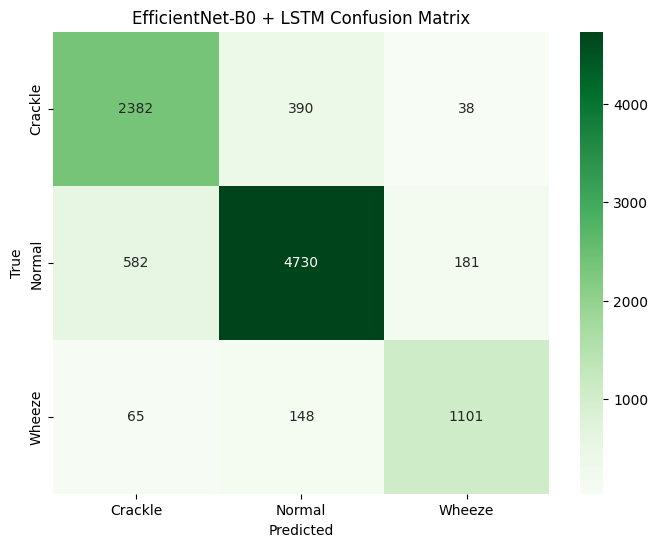


📈 GENERATING ROC-AUC CURVE...


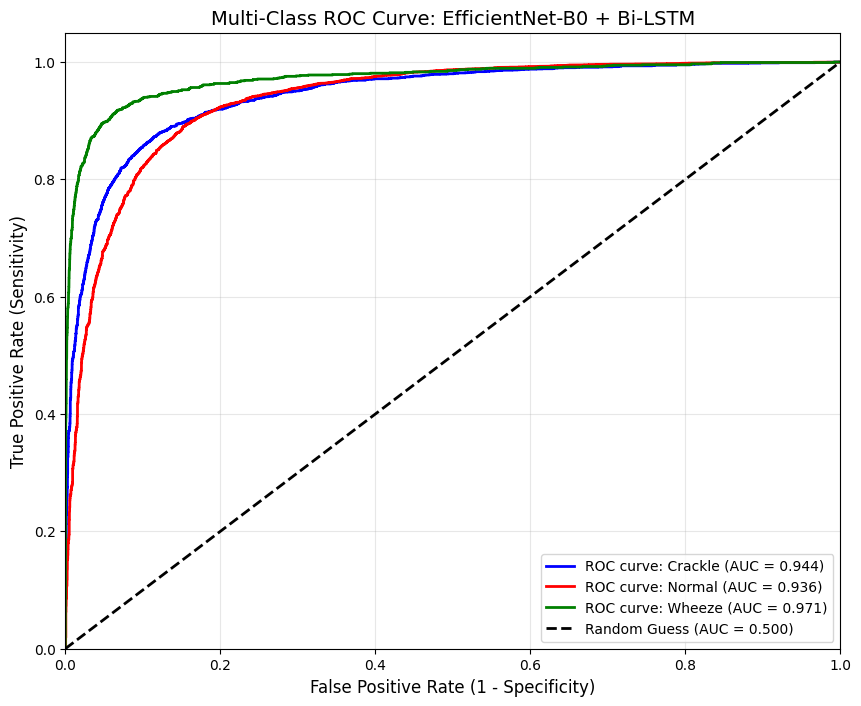

✅ ROC Curve saved to: results_sota\efficientnet_roc_curve.png
✅ Best Model successfully saved to: ./saved_models/efficientnet_b0.pth


In [8]:
import os
import sys
import subprocess
import numpy as np
import pandas as pd
import scipy.signal
from tqdm import tqdm
from itertools import cycle # <--- NEW IMPORT

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize # <--- NEW IMPORT
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc # <--- NEW IMPORTS
from sklearn.utils.class_weight import compute_class_weight

# --- 1. SETUP & IMPORTS ---
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torchvision.models as models
    import librosa
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    print("⚠️ Installing missing libraries...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "torchaudio", "librosa", "matplotlib", "scikit-learn", "tqdm", "pandas", "scipy", "seaborn"])
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    import torchvision.models as models
    import librosa
    import matplotlib.pyplot as plt
    import seaborn as sns

# --- 2. GPU SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ DEVICE STATUS: {device}")
if torch.cuda.is_available():
    print(f"   GPU Detected: {torch.cuda.get_device_name(0)}")

# --- 3. CONFIGURATION ---
DATASET_DIR = 'dataset'
SAVE_DIR = 'results_sota'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('./saved_models', exist_ok=True) 

SAMPLE_RATE = 16000
MAX_DURATION = 5.0
MAX_SAMPLES = int(MAX_DURATION * SAMPLE_RATE)
N_MFCC = 13
N_MELS = 128
PREEMPHASIS_COEF = 0.97 

# --- 4. PREPROCESSING UTILS ---
def spec_augment(spec, num_mask=2, freq_masking=15, time_masking=20):
    spec = spec.clone()
    if spec.dim() == 4:
        freq_axis = 2
        time_axis = 3
    elif spec.dim() == 3:
        freq_axis = 1
        time_axis = 2
    else:
        return spec 
        
    for _ in range(num_mask):
        f = np.random.randint(1, freq_masking)
        f_max = spec.shape[freq_axis] - f
        if f_max > 0:
            f0 = np.random.randint(0, f_max)
            if spec.dim() == 4:
                spec[:, :, f0:f0+f, :] = 0
            else:
                spec[:, f0:f0+f, :] = 0

        t = np.random.randint(1, time_masking)
        t_max = spec.shape[time_axis] - t
        if t_max > 0:
            t0 = np.random.randint(0, t_max)
            if spec.dim() == 4:
                spec[:, :, :, t0:t0+t] = 0
            else:
                spec[:, :, t0:t0+t] = 0
    return spec

def preemphasis(signal, coeff=0.97):
    return np.append(signal[0], signal[1:] - coeff * signal[:-1])

def fix_length(y):
    if len(y) > MAX_SAMPLES:
        start = np.random.randint(0, len(y) - MAX_SAMPLES)
        return y[start : start + MAX_SAMPLES]
    else:
        return np.pad(y, (0, MAX_SAMPLES - len(y)))

def extract_features(y, sr):
    y = preemphasis(y, coeff=PREEMPHASIS_COEF)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=512)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    cnn_input = mel_db.astype(np.float32) 
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=512)
    lstm_input = mfcc.T.astype(np.float32) 
    return cnn_input, lstm_input

def augment_audio(y, sr):
    augmented = [y]
    if np.random.rand() > 0.5: 
        steps = np.random.randint(-2, 2)
        try:
            y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)
            augmented.append(fix_length(y_pitch))
        except: pass
    return augmented

# --- 5. DATA LOADING ---
def load_data(path):
    X_cnn, X_lstm, y_labels = [], [], []
    wav_files = []
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.endswith('.wav'):
                wav_files.append(os.path.join(root, f))
    
    print(f"--- Loading & Augmenting Audio ---")
    for wav_path in tqdm(wav_files):
        try:
            y, sr = librosa.load(wav_path, sr=SAMPLE_RATE)
            txt_file = wav_path.replace('.wav', '.txt')
            if os.path.exists(txt_file):
                df_labels = pd.read_csv(txt_file, sep='\t', names=['start','end','c','w'])
                for _, row in df_labels.iterrows():
                     if row['end'] - row['start'] < 0.2: continue 
                     y_seg = y[int(row['start']*sr):int(row['end']*sr)]
                     if len(y_seg) == 0: continue
                     
                     label = 'Normal'
                     if row['c'] == 1 and row['w'] == 1: label = 'Both'
                     elif row['c'] == 1: label = 'Crackle'
                     elif row['w'] == 1: label = 'Wheeze'
                     if label == 'Both': continue 
                     
                     variations = augment_audio(fix_length(y_seg), sr)
                     for v in variations:
                         xc, xl = extract_features(v, sr)
                         X_cnn.append(xc)
                         X_lstm.append(xl)
                         y_labels.append(label)
        except: pass
    return np.array(X_cnn), np.array(X_lstm), np.array(y_labels)

# --- 6. THE SOTA MODEL (EfficientNet + LSTM) ---
class SOTADualModel(nn.Module):
    def __init__(self, num_classes):
        super(SOTADualModel, self).__init__()
        
        # EfficientNet B0 Setup
        try:
            weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
            self.cnn = models.efficientnet_b0(weights=weights)
        except:
            self.cnn = models.efficientnet_b0(pretrained=True)
        
        original_layer = self.cnn.features[0][0]
        self.cnn.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        
        with torch.no_grad():
            self.cnn.features[0][0].weight.data = original_layer.weight.data.mean(dim=1, keepdim=True)
        
        self.cnn.classifier = nn.Identity()
        
        self.lstm = nn.LSTM(input_size=13, hidden_size=128, num_layers=2, batch_first=True, bidirectional=True)
        
        self.fusion = nn.Sequential(
            nn.Linear(1280 + 256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x_cnn, x_lstm):
        x_cnn = nn.functional.interpolate(x_cnn, size=(224, 224), mode='bilinear', align_corners=False)
        features_cnn = self.cnn(x_cnn) 
        _, (h_n, _) = self.lstm(x_lstm)
        features_lstm = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1) 
        combined = torch.cat((features_cnn, features_lstm), dim=1)
        return self.fusion(combined)

class LungDataset(Dataset):
    def __init__(self, X_cnn, X_lstm, y):
        self.X_cnn = X_cnn
        self.X_lstm = X_lstm
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        c = torch.tensor(self.X_cnn[idx], dtype=torch.float32).unsqueeze(0)
        l = torch.tensor(self.X_lstm[idx], dtype=torch.float32)
        return c, l, self.y[idx]

# --- 7. MAIN TRAINING LOOP ---
if __name__ == "__main__":
    X_cnn, X_lstm, y_raw = load_data(DATASET_DIR)
    le = LabelEncoder()
    y_enc = le.fit_transform(y_raw)
    classes = le.classes_
    print(f"✅ Data Ready: {len(X_cnn)} samples. Classes: {classes}")

    class_weights = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print(f"⚖️ Class Weights: {class_weights}")

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # --- NEW: Added global_probs ---
    global_trues, global_preds, global_probs = [], [], []
    best_overall_acc = 0

    best_fold_model_state = None
    best_fold_acc_tracker = 0

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cnn, y_enc)):
        print(f"\n🔹 Fold {fold+1}/5 (EfficientNet-B0 + LSTM)")
        
        train_ds = LungDataset(X_cnn[train_idx], X_lstm[train_idx], y_enc[train_idx])
        val_ds = LungDataset(X_cnn[val_idx], X_lstm[val_idx], y_enc[val_idx])
        
        # --- FIX: Added drop_last=True ---
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
        val_loader = DataLoader(val_ds, batch_size=32, num_workers=0)
        
        model = SOTADualModel(len(classes)).to(device)
        optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        
        best_fold_acc = 0
        
        for epoch in range(100): 
            model.train()
            train_loss = 0
            for xc, xl, y in train_loader:
                xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                
                if np.random.rand() > 0.4:
                    xc = spec_augment(xc)
                
                optimizer.zero_grad()
                out = model(xc, xl)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            
            scheduler.step()
            
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for xc, xl, y in val_loader:
                    xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                    out = model(xc, xl)
                    _, pred = torch.max(out, 1)
                    total += y.size(0)
                    correct += (pred == y).sum().item()
            
            acc = 100 * correct / total
            if acc > best_fold_acc: 
                best_fold_acc = acc
                if acc > best_fold_acc_tracker:
                    best_fold_acc_tracker = acc
                    best_fold_model_state = model.state_dict()

            print(f"   Epoch {epoch+1:02d}: Loss {train_loss/len(train_loader):.4f} | Val Acc {acc:.2f}%", end='\r')
        
        print(f"\n   > Best Fold Acc: {best_fold_acc:.2f}%")
        
        # --- NEW: Extract Probabilities ---
        with torch.no_grad():
            for xc, xl, y in val_loader:
                xc, xl, y = xc.to(device), xl.to(device), y.to(device)
                out = model(xc, xl)
                
                probs = torch.softmax(out, dim=1) # Get Confidence Scores
                _, pred = torch.max(out, 1)
                
                global_trues.extend(y.cpu().numpy())
                global_preds.extend(pred.cpu().numpy())
                global_probs.extend(probs.cpu().numpy())

    # --- 8. RESULTS ---
    print("\n\n📊 FINAL EFFICIENTNET RESULTS")
    print(classification_report(global_trues, global_preds, target_names=classes))
    
    # Confusion Matrix
    cm = confusion_matrix(global_trues, global_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
    plt.title("EfficientNet-B0 + LSTM Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(os.path.join(SAVE_DIR, 'efficientnet_confusion_matrix.png'))
    plt.show()

    # --- 9. ROC & AUC CURVES ---
    print("\n📈 GENERATING ROC-AUC CURVE...")
    
    y_bin = label_binarize(global_trues, classes=range(len(classes)))
    n_classes = y_bin.shape[1]
    global_probs_arr = np.array(global_probs)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], global_probs_arr[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'purple', 'orange'])
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve: {classes[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Multi-Class ROC Curve: EfficientNet-B0 + Bi-LSTM', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    
    roc_path = os.path.join(SAVE_DIR, 'efficientnet_roc_curve.png')
    plt.savefig(roc_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ ROC Curve saved to: {roc_path}")

    # Save Model
    if best_fold_model_state:
        save_path = './saved_models/efficientnet_b0.pth'
        torch.save(best_fold_model_state, save_path)
        print(f"✅ Best Model successfully saved to: {save_path}")